# 6. The Training Loop

You have the components: Model, Loss, Optimizer.
Now let's put them together in a **Training Loop**.
This is the heartbeat of deep learning.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

## 1. The 4 Steps of Training

For every batch of data:
1. **Forward Pass**: Compute predictions.
2. **Compute Loss**: How bad were the predictions?
3. **Backward Pass**: Calculate gradients (`loss.backward()`).
4. **Optimizer Step**: Update weights (`optimizer.step()`).

**Crucial Step**: Don't forget `optimizer.zero_grad()` before backward!

In [ ]:
# 1. Data (Linear Regression: y = 2x + 1)
X = torch.linspace(0, 10, 100).view(-1, 1)
y = 2 * X + 1 + torch.randn(100, 1) * 0.5 # Add noise

# 2. Model
model = nn.Linear(1, 1)

# 3. Loss and Optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Training Loop
epochs = 100
losses = []

for epoch in range(epochs):
    # Step 0: Zero gradients (otherwise they accumulate!)
    optimizer.zero_grad()
    
    # Step 1: Forward Pass
    y_pred = model(X)
    
    # Step 2: Compute Loss
    loss = criterion(y_pred, y)
    losses.append(loss.item())
    
    # Step 3: Backward Pass
    loss.backward()
    
    # Step 4: Update Weights
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

print("Training Complete!")

Epoch 0: Loss = 219.9503
Epoch 10: Loss = 0.3202
Epoch 20: Loss = 0.3193
Epoch 30: Loss = 0.3185
Epoch 40: Loss = 0.3178
Epoch 50: Loss = 0.3171
Epoch 60: Loss = 0.3165
Epoch 70: Loss = 0.3160
Epoch 80: Loss = 0.3155
Epoch 90: Loss = 0.3151
Training Complete!


## 2. Visualizing Results

Let's see if the model learned the line $y = 2x + 1$.

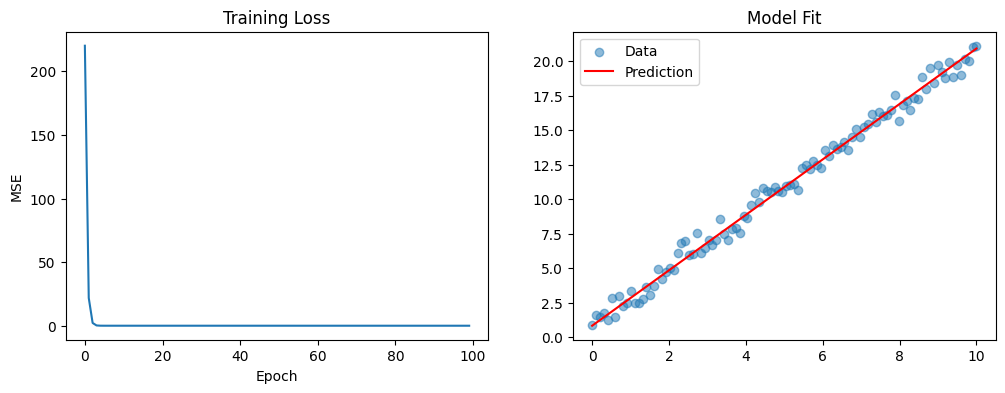

Learned Weights: w=2.01, b=0.82
True Weights:    w=2.00, b=1.00


In [3]:
# Plot Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")

# Plot Predictions
plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.5, label="Data")
plt.plot(X, model(X).detach(), 'r', label="Prediction")
plt.title("Model Fit")
plt.legend()
plt.show()

print(f"Learned Weights: w={model.weight.item():.2f}, b={model.bias.item():.2f}")
print("True Weights:    w=2.00, b=1.00")

## 3. Common Pitfalls

1. **Forgetting `zero_grad()`**: Gradients will add up, leading to huge updates and exploding loss.
2. **Wrong Learning Rate**: 
    - Too high: Loss explodes (NaN).
    - Too low: Loss doesn't decrease.
3. **Not detaching for plotting**: `model(X)` has gradients. Use `.detach()` or `with torch.no_grad():` when plotting or evaluating.